# Mel Spectrogram Analysis

Visualize prior and output mel spectrograms saved by the VocaloFlow inference pipeline (`--save-mels` flag).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

# SoulX-Singer mel normalization constants (z-score)
MEL_MEAN = -4.92
MEL_VAR = 8.14

# Frame timing: hop=480, sr=24000 => 20ms per frame
FRAME_SEC = 0.02

# ── Configure source directories here ──
SOURCE_DIRS = [
    Path("../demo/let_it_go/4-16-wavenet"),
    # Path("../demo/let_it_go/4-15-wavenet"),
    # Path("../demo/let_it_go/4-13-stft"),
    # Path("../demo/let_it_go/4-13-deep-convnet"),
    # Path("../demo/we_are_charlie"),
    # Path("../VocalPrompts/Rachie"),
]

In [13]:
def load_mels(source_dir, i=0):
    """Load prior and output mel .npy files from a directory."""
    source_dir = Path(source_dir)
    prior_files = sorted(source_dir.glob("*_prior_mel.npy"))
    output_files = [
        f for f in sorted(source_dir.glob("*_mel.npy"))
        if "_prior_mel.npy" not in f.name
    ]
    if not prior_files or not output_files:
        raise FileNotFoundError(
            f"Missing mel .npy files in {source_dir}. "
            f"Run inference with --save-mels first."
        )
    prior_mel = np.load(prior_files[i])   # (T, 128)
    output_mel = np.load(output_files[i]) # (T, 128)

    #print names
    print(f"[load_mels] Loaded prior mel: {prior_files[i].name}, "
          f"output mel: {output_files[i].name} from {source_dir.name}")
    return prior_mel, output_mel, source_dir.name


def denormalize_mel(mel):
    """Reverse z-score: mel * sqrt(var) + mean."""
    return mel * math.sqrt(MEL_VAR) + MEL_MEAN


def time_axis(n_frames):
    """Return time values in seconds for n_frames."""
    return np.arange(n_frames) * FRAME_SEC

## Side-by-Side: Prior vs Output Mel Spectrograms

[load_mels] Loaded prior mel: output_prior_mel.npy, output mel: output_mel.npy from 4-15-wavenet


C:\Users\archi\AppData\Local\Temp\ipykernel_89324\2772249749.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


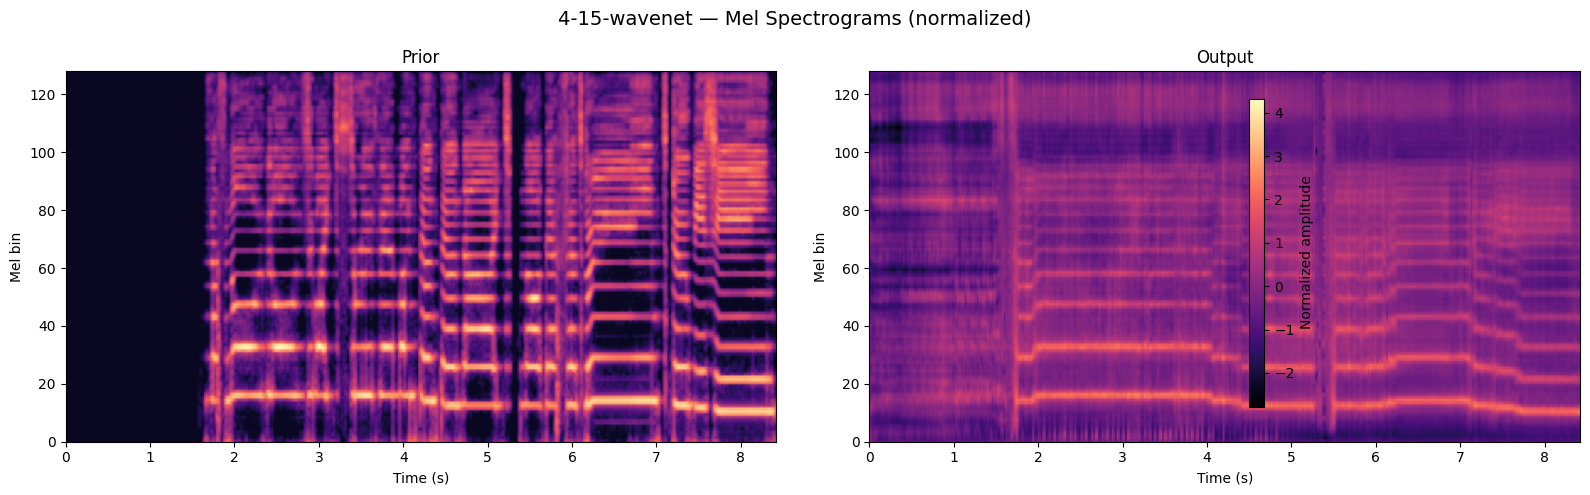

[load_mels] Loaded prior mel: output_prior_mel.npy, output mel: output_mel.npy from 4-13-stft


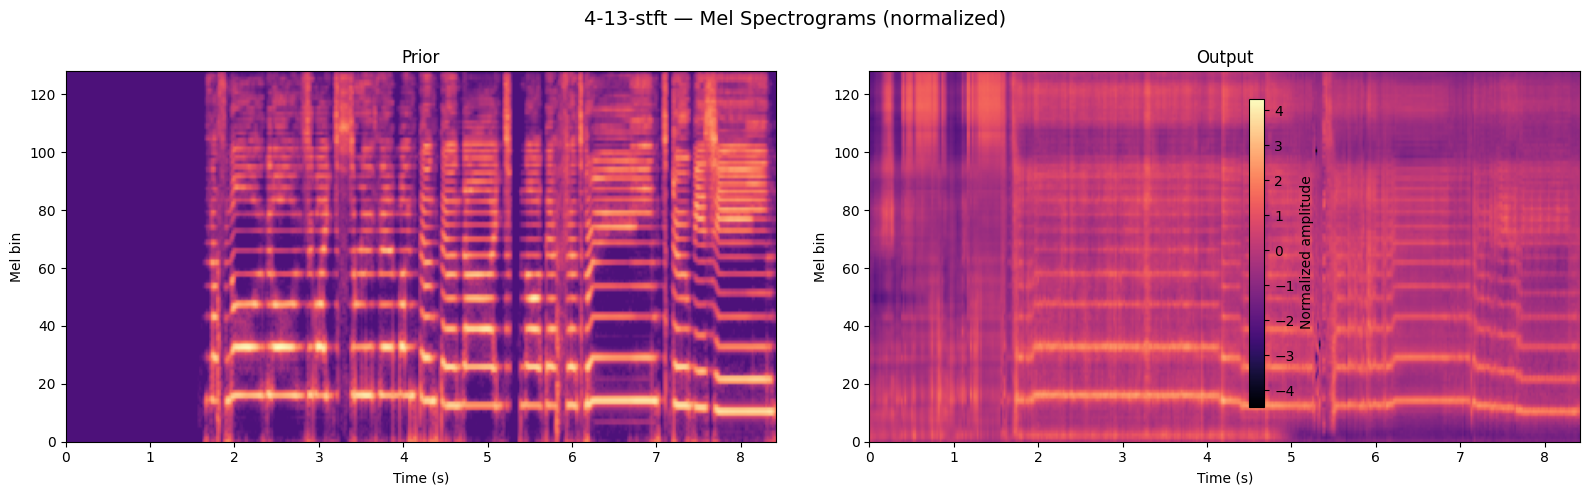

[load_mels] Loaded prior mel: output_prior_mel.npy, output mel: output_mel.npy from 4-13-deep-convnet


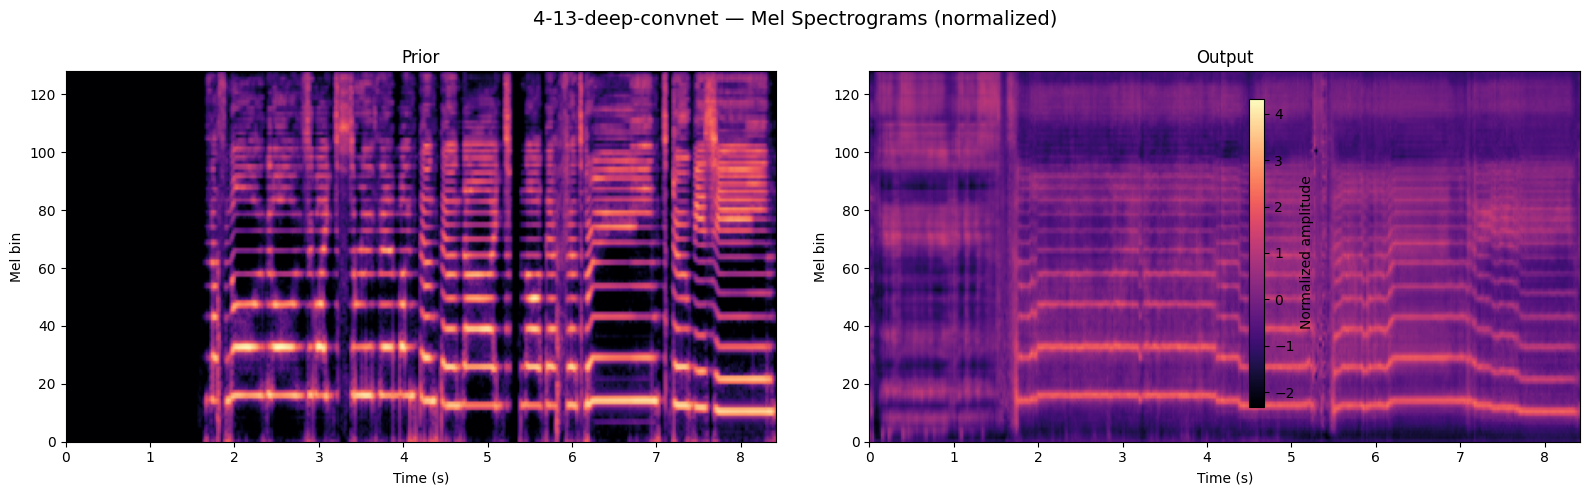

In [14]:
for src in SOURCE_DIRS:
    prior_mel, output_mel, name = load_mels(src)
    T = prior_mel.shape[0]
    t = time_axis(T)

    vmin = min(prior_mel.min(), output_mel.min())
    vmax = max(prior_mel.max(), output_mel.max())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"{name} — Mel Spectrograms (normalized)", fontsize=14)

    for ax, mel, title in [
        (axes[0], prior_mel, "Prior"),
        (axes[1], output_mel, "Output"),
    ]:
        im = ax.imshow(
            mel.T, origin="lower", aspect="auto",
            cmap="magma", vmin=vmin, vmax=vmax,
            extent=[t[0], t[-1], 0, 128],
        )
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Mel bin")

    fig.colorbar(im, ax=axes, shrink=0.8, label="Normalized amplitude")
    plt.tight_layout()
    plt.show()

## Difference: What the Model Changed

Blue = model reduced energy, Red = model added energy.

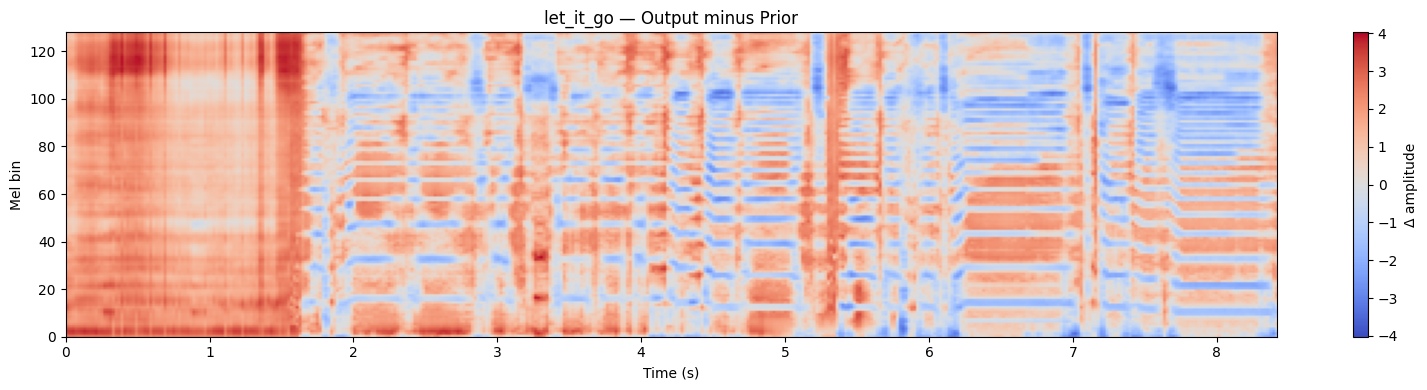

  mean |Δ| = 1.1769,  max |Δ| = 4.0226


In [4]:
for src in SOURCE_DIRS:
    prior_mel, output_mel, name = load_mels(src)
    T = prior_mel.shape[0]
    t = time_axis(T)
    diff = output_mel - prior_mel
    vlim = np.abs(diff).max()

    fig, ax = plt.subplots(figsize=(16, 4))
    im = ax.imshow(
        diff.T, origin="lower", aspect="auto",
        cmap="coolwarm", vmin=-vlim, vmax=vlim,
        extent=[t[0], t[-1], 0, 128],
    )
    ax.set_title(f"{name} — Output minus Prior")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mel bin")
    fig.colorbar(im, ax=ax, label="Δ amplitude")
    plt.tight_layout()
    plt.show()

    print(f"  mean |Δ| = {np.abs(diff).mean():.4f},  max |Δ| = {vlim:.4f}")